# Project Overheat: Predictive Maintenance AI

### Predictive Maintenance Using IoT Sensor Telemetry

This project predicts whether a catastrophic machine failure will occur within the next 24 hours using IoT sensor telemetry and a Random Forest classification model.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving iot sensor telemetry .csv to iot sensor telemetry .csv


In [3]:
import os

print(os.listdir())

['.config', 'iot sensor telemetry .csv', 'iot_sensor_telemetry  (2).csv', 'sample_data']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
file_path = "iot sensor telemetry .csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 5)


In [7]:
df.head()

,Timestamp,Sensor_Temp_C,Sensor_Vibration_mm,Sensor_Voltage_V,Catastrophic_Failure
0,2023-01-01 00:00:00,66.490142,1.064301,220.696572,0.0
1,2023-01-01 01:00:00,64.585207,1.138900,220.566647,0.0
2,2023-01-01 02:00:00,66.943066,1.080524,218.126960,0.0
3,2023-01-01 03:00:00,69.569090,1.222084,221.159168,0.0
4,2023-01-01 04:00:00,64.297540,1.439436,217.019835,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             10000 non-null  object 
 1   Sensor_Temp_C         10000 non-null  float64
 2   Sensor_Vibration_mm   10000 non-null  float64
 3   Sensor_Voltage_V      10000 non-null  float64
 4   Catastrophic_Failure  10000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 390.8+ KB


In [9]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (10000, 5)

Column names:
['Timestamp', 'Sensor_Temp_C', 'Sensor_Vibration_mm', 'Sensor_Voltage_V', 'Catastrophic_Failure']

Missing values:
Timestamp               0
Sensor_Temp_C           0
Sensor_Vibration_mm     0
Sensor_Voltage_V        0
Catastrophic_Failure    0
dtype: int64


In [10]:
print("Catastrophic Failure Distribution:")
print(df["Catastrophic_Failure"].value_counts())

print("\nFailure percentages:")
print(df["Catastrophic_Failure"].value_counts(normalize=True) * 100)

Catastrophic Failure Distribution:
Catastrophic_Failure
0.0    9985
1.0      15
Name: count, dtype: int64

Failure percentages:
Catastrophic_Failure
0.0    99.85
1.0     0.15
Name: proportion, dtype: float64


In [11]:
# Convert Timestamp to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Sort data chronologically
df = df.sort_values("Timestamp").reset_index(drop=True)

# Check the result
print("Timestamp data type:", df["Timestamp"].dtype)
print("First timestamp:", df["Timestamp"].iloc[0])
print("Last timestamp:", df["Timestamp"].iloc[-1])

Timestamp data type: datetime64[ns]
First timestamp: 2023-01-01 00:00:00
Last timestamp: 2024-02-21 15:00:00


In [12]:
time_diff = df["Timestamp"].diff().dropna()

print("Unique time intervals:")
print(time_diff.value_counts())


Unique time intervals:
Timestamp
0 days 01:00:00    9999
Name: count, dtype: int64


In [13]:
# Create 12-hour rolling temperature mean
df["Temp_Rolling_Mean_12h"] = (
    df["Sensor_Temp_C"].rolling(window=12).mean()
)

# Create 12-hour rolling vibration standard deviation
df["Vibration_Rolling_Std_12h"] = (
    df["Sensor_Vibration_mm"].rolling(window=12).std()
)

print("12-hour rolling features created successfully!")

12-hour rolling features created successfully!


In [ ]:
print(df[
    [
        "Timestamp",
        "Sensor_Temp_C",
        "Temp_Rolling_Mean_12h",
        "Sensor_Vibration_mm",
        "Vibration_Rolling_Std_12h"
    ]
].head(15))



             Timestamp  Sensor_Temp_C  Temp_Rolling_Mean_12h  \
0  2023-01-01 00:00:00      66.490142                    NaN   
1  2023-01-01 01:00:00      64.585207                    NaN   
2  2023-01-01 02:00:00      66.943066                    NaN   
3  2023-01-01 03:00:00      69.569090                    NaN   
4  2023-01-01 04:00:00      64.297540                    NaN   
5  2023-01-01 05:00:00      64.297589                    NaN   
6  2023-01-01 06:00:00      69.737638                    NaN   
7  2023-01-01 07:00:00      67.302304                    NaN   
8  2023-01-01 08:00:00      63.591577                    NaN   
9  2023-01-01 09:00:00      66.627680                    NaN   
10 2023-01-01 10:00:00      63.609747                    NaN   
11 2023-01-01 11:00:00      63.602811              65.887866   
12 2023-01-01 12:00:00      65.725887              65.824178   
13 2023-01-01 13:00:00      59.260159              65.380424   
14 2023-01-01 14:00:00      59.825247   

In [14]:
# Check missing values in the rolling features
print("Missing values before dropping:")
print(df[[
    "Temp_Rolling_Mean_12h",
    "Vibration_Rolling_Std_12h"
]].isnull().sum())

# Drop rows where rolling features are NaN
df = df.dropna(
    subset=[
        "Temp_Rolling_Mean_12h",
        "Vibration_Rolling_Std_12h"
    ]
).reset_index(drop=True)

print("\nMissing values after dropping:")
print(df[[
    "Temp_Rolling_Mean_12h",
    "Vibration_Rolling_Std_12h"
]].isnull().sum())

print("\nNew dataset shape:", df.shape)

Missing values before dropping:
Temp_Rolling_Mean_12h        11
Vibration_Rolling_Std_12h    11
dtype: int64

Missing values after dropping:
Temp_Rolling_Mean_12h        0
Vibration_Rolling_Std_12h    0
dtype: int64

New dataset shape: (9989, 7)


In [15]:
# Create the target: whether a catastrophic failure occurs in 24 hours
df["Failure_In_24_Hours"] = df["Catastrophic_Failure"].shift(-24)

print("Target column created successfully!")
print(df[[
    "Timestamp",
    "Catastrophic_Failure",
    "Failure_In_24_Hours"
]].head(10))


Target column created successfully!
            Timestamp  Catastrophic_Failure  Failure_In_24_Hours
0 2023-01-01 11:00:00                   0.0                  0.0
1 2023-01-01 12:00:00                   0.0                  0.0
2 2023-01-01 13:00:00                   0.0                  0.0
3 2023-01-01 14:00:00                   0.0                  0.0
4 2023-01-01 15:00:00                   0.0                  0.0
5 2023-01-01 16:00:00                   0.0                  0.0
6 2023-01-01 17:00:00                   0.0                  0.0
7 2023-01-01 18:00:00                   0.0                  0.0
8 2023-01-01 19:00:00                   0.0                  0.0
9 2023-01-01 20:00:00                   0.0                  0.0


In [16]:
print("Missing values in Failure_In_24_Hours:")
print(df["Failure_In_24_Hours"].isnull().sum())

Missing values in Failure_In_24_Hours:
24


In [17]:
# Remove rows where the 24-hour future target is unknown
df = df.dropna(subset=["Failure_In_24_Hours"]).reset_index(drop=True)

# Convert target from float to integer
df["Failure_In_24_Hours"] = df["Failure_In_24_Hours"].astype(int)

print("Rows after removing final 24 rows:", len(df))
print("\nTarget data type:", df["Failure_In_24_Hours"].dtype)
print("\nTarget distribution:")
print(df["Failure_In_24_Hours"].value_counts())

Rows after removing final 24 rows: 9965

Target data type: int64

Target distribution:
Failure_In_24_Hours
0    9950
1      15
Name: count, dtype: int64


In [18]:
# Remove the original failure label to prevent target leakage
df = df.drop(columns=["Catastrophic_Failure"])

print("Catastrophic_Failure removed successfully.")
print("\nFinal columns:")
print(df.columns.tolist())

print("\nFinal dataset shape:", df.shape)

Catastrophic_Failure removed successfully.

Final columns:
['Timestamp', 'Sensor_Temp_C', 'Sensor_Vibration_mm', 'Sensor_Voltage_V', 'Temp_Rolling_Mean_12h', 'Vibration_Rolling_Std_12h', 'Failure_In_24_Hours']

Final dataset shape: (9965, 7)


In [19]:
# Define the features used by the machine learning model
feature_columns = [
    "Sensor_Temp_C",
    "Sensor_Vibration_mm",
    "Sensor_Voltage_V",
    "Temp_Rolling_Mean_12h",
    "Vibration_Rolling_Std_12h"
]

target_column = "Failure_In_24_Hours"

X = df[feature_columns]
y = df[target_column]

print("Features:")
print(feature_columns)

print("\nTarget:")
print(target_column)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['Sensor_Temp_C', 'Sensor_Vibration_mm', 'Sensor_Voltage_V', 'Temp_Rolling_Mean_12h', 'Vibration_Rolling_Std_12h']

Target:
Failure_In_24_Hours

X shape: (9965, 5)
y shape: (9965,)


In [20]:
# Calculate the 80% split point
split_index = int(len(df) * 0.80)

# Chronological train-test split
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(df["Timestamp"].iloc[0], "to", df["Timestamp"].iloc[split_index - 1])

print("\nTesting period:")
print(df["Timestamp"].iloc[split_index], "to", df["Timestamp"].iloc[-1])

Training samples: 7972
Testing samples: 1993

Training period:
2023-01-01 11:00:00 to 2023-11-29 14:00:00

Testing period:
2023-11-29 15:00:00 to 2024-02-20 15:00:00


In [21]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
Failure_In_24_Hours
0    7960
1      12
Name: count, dtype: int64

Testing target distribution:
Failure_In_24_Hours
0    1990
1       3
Name: count, dtype: int64


In [22]:
# Create the Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [23]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("Number of test predictions:", len(y_pred))

Predictions generated successfully!
Number of test predictions: 1993


In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Model Evaluation Metrics")
print("------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Model Evaluation Metrics
------------------------
Accuracy : 0.9985
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000


In [25]:
print("Classification Report")
print("---------------------")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Failure", "Failure Within 24 Hours"],
    zero_division=0
))

Classification Report
---------------------
                         precision    recall  f1-score   support

             No Failure       1.00      1.00      1.00      1990
Failure Within 24 Hours       0.00      0.00      0.00         3

               accuracy                           1.00      1993
              macro avg       0.50      0.50      0.50      1993
           weighted avg       1.00      1.00      1.00      1993



Confusion Matrix:
[[1990    0]
 [   3    0]]


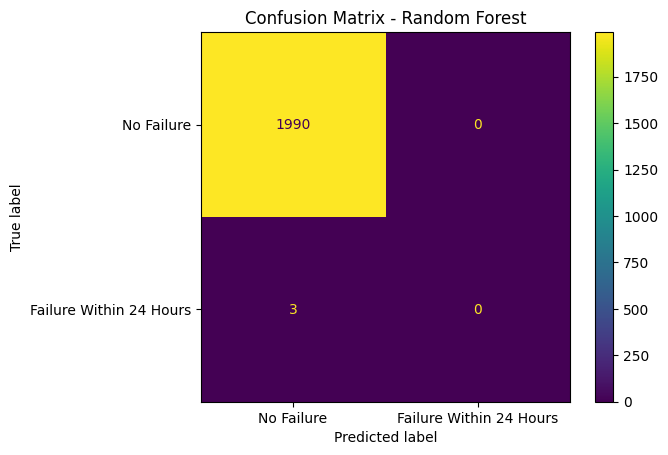

In [26]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure Within 24 Hours"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [27]:
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9962


In [28]:
print("Predicted probability statistics:")
print(pd.Series(y_prob).describe())

print("\nHighest predicted probabilities:")
print(
    pd.DataFrame({
        "Actual": y_test.values,
        "Failure_Probability": y_prob
    })
    .sort_values("Failure_Probability", ascending=False)
    .head(20)
)

Predicted probability statistics:
count    1993.000000
mean        0.001335
std         0.016180
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.375000
dtype: float64

Highest predicted probabilities:
      Actual  Failure_Probability
1503       0                0.375
1440       0                0.330
1439       1                0.280
1209       0                0.245
1502       1                0.175
1207       0                0.150
1435       0                0.130
1505       0                0.130
1204       0                0.100
1442       0                0.090
1212       0                0.080
1202       0                0.070
1441       0                0.070
1504       0                0.065
1501       0                0.055
1438       0                0.050
1210       0                0.040
1206       0                0.035
1511       0                0.030
1213       0                0.025


In [29]:
actual_failures = pd.DataFrame({
    "Actual": y_test.values,
    "Failure_Probability": y_prob
})

actual_failures = actual_failures[actual_failures["Actual"] == 1]

print("Actual test failures and their predicted probabilities:")
print(actual_failures)

Actual test failures and their predicted probabilities:
      Actual  Failure_Probability
1208       1                0.025
1439       1                0.280
1502       1                0.175


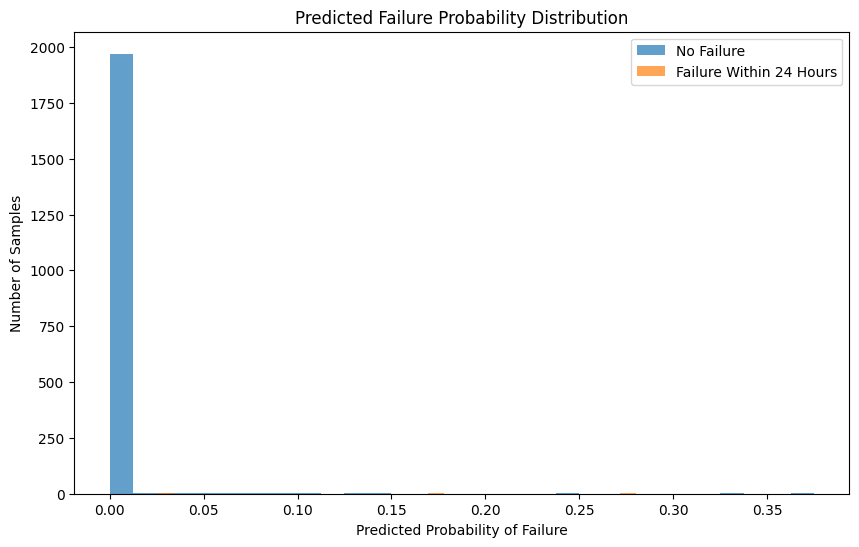

In [30]:
plt.figure(figsize=(10, 6))

plt.hist(
    y_prob[y_test.values == 0],
    bins=30,
    alpha=0.7,
    label="No Failure"
)

plt.hist(
    y_prob[y_test.values == 1],
    bins=30,
    alpha=0.7,
    label="Failure Within 24 Hours"
)

plt.xlabel("Predicted Probability of Failure")
plt.ylabel("Number of Samples")
plt.title("Predicted Failure Probability Distribution")
plt.legend()
plt.show()

In [31]:
thresholds = [0.50, 0.30, 0.20, 0.10, 0.05, 0.01]

print("Threshold Performance")
print("---------------------")

for threshold in thresholds:
    threshold_pred = (y_prob >= threshold).astype(int)

    recall = recall_score(y_test, threshold_pred, zero_division=0)
    precision = precision_score(y_test, threshold_pred, zero_division=0)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Recall: {recall:.4f} | "
        f"Precision: {precision:.4f}"
    )

Threshold Performance
---------------------
Threshold: 0.50 | Recall: 0.0000 | Precision: 0.0000
Threshold: 0.30 | Recall: 0.0000 | Precision: 0.0000
Threshold: 0.20 | Recall: 0.3333 | Precision: 0.2500
Threshold: 0.10 | Recall: 0.6667 | Precision: 0.2222
Threshold: 0.05 | Recall: 0.6667 | Precision: 0.1250
Threshold: 0.01 | Recall: 1.0000 | Precision: 0.1154


In [32]:
validation_split = int(len(X_train) * 0.80)

X_train_model = X_train.iloc[:validation_split]
X_validation = X_train.iloc[validation_split:]

y_train_model = y_train.iloc[:validation_split]
y_validation = y_train.iloc[validation_split:]

print("Training samples:", len(X_train_model))
print("Validation samples:", len(X_validation))

print("\nTraining failures:", y_train_model.sum())
print("Validation failures:", y_validation.sum())

Training samples: 6377
Validation samples: 1595

Training failures: 10
Validation failures: 2


In [33]:
rf_validation_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_validation_model.fit(X_train_model, y_train_model)

print("Validation Random Forest trained successfully!")

Validation Random Forest trained successfully!


In [34]:
validation_prob = rf_validation_model.predict_proba(X_validation)[:, 1]

print("Validation probabilities generated successfully!")
print("Highest validation probability:", validation_prob.max())

Validation probabilities generated successfully!
Highest validation probability: 0.35


In [35]:
validation_thresholds = [0.50, 0.30, 0.20, 0.10, 0.05, 0.01]

print("Validation Threshold Performance")
print("--------------------------------")

for threshold in validation_thresholds:
    validation_pred = (validation_prob >= threshold).astype(int)

    recall = recall_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    precision = precision_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Recall: {recall:.4f} | "
        f"Precision: {precision:.4f}"
    )

Validation Threshold Performance
--------------------------------
Threshold: 0.50 | Recall: 0.0000 | Precision: 0.0000
Threshold: 0.30 | Recall: 0.0000 | Precision: 0.0000
Threshold: 0.20 | Recall: 0.5000 | Precision: 0.3333
Threshold: 0.10 | Recall: 0.5000 | Precision: 0.1667
Threshold: 0.05 | Recall: 0.5000 | Precision: 0.0909
Threshold: 0.01 | Recall: 1.0000 | Precision: 0.0769


In [36]:
best_threshold = None
best_recall = -1
best_precision = -1

for threshold in np.arange(0.01, 0.51, 0.01):
    validation_pred = (validation_prob >= threshold).astype(int)

    recall = recall_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    precision = precision_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    if recall > best_recall or (
        recall == best_recall and precision > best_precision
    ):
        best_threshold = threshold
        best_recall = recall
        best_precision = precision

print(f"Selected threshold: {best_threshold:.2f}")
print(f"Validation Recall: {best_recall:.4f}")
print(f"Validation Precision: {best_precision:.4f}")

Selected threshold: 0.03
Validation Recall: 1.0000
Validation Precision: 0.1111


In [37]:
y_test_threshold_pred = (
    y_prob >= best_threshold
).astype(int)

print("Threshold-based test predictions generated!")
print("Selected threshold:", round(best_threshold, 2))

Threshold-based test predictions generated!
Selected threshold: 0.03


In [38]:
threshold_accuracy = accuracy_score(
    y_test,
    y_test_threshold_pred
)

threshold_precision = precision_score(
    y_test,
    y_test_threshold_pred,
    zero_division=0
)

threshold_recall = recall_score(
    y_test,
    y_test_threshold_pred,
    zero_division=0
)

threshold_f1 = f1_score(
    y_test,
    y_test_threshold_pred,
    zero_division=0
)

print("Threshold-Based Test Performance")
print("--------------------------------")
print(f"Accuracy : {threshold_accuracy:.4f}")
print(f"Precision: {threshold_precision:.4f}")
print(f"Recall   : {threshold_recall:.4f}")
print(f"F1 Score : {threshold_f1:.4f}")

Threshold-Based Test Performance
--------------------------------
Accuracy : 0.9910
Precision: 0.1053
Recall   : 0.6667
F1 Score : 0.1818


Threshold-Based Confusion Matrix:
[[1973   17]
 [   1    2]]


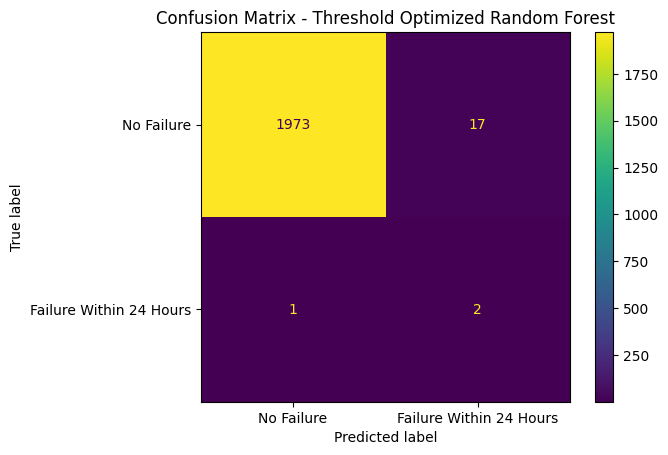

In [39]:
threshold_cm = confusion_matrix(
    y_test,
    y_test_threshold_pred
)

print("Threshold-Based Confusion Matrix:")
print(threshold_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=threshold_cm,
    display_labels=["No Failure", "Failure Within 24 Hours"]
)

disp.plot()
plt.title("Confusion Matrix - Threshold Optimized Random Forest")
plt.show()

In [40]:
print("Final Threshold-Based Test Metrics")
print("----------------------------------")

print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {threshold_accuracy:.4f}")
print(f"Precision : {threshold_precision:.4f}")
print(f"Recall    : {threshold_recall:.4f}")
print(f"F1 Score  : {threshold_f1:.4f}")

Final Threshold-Based Test Metrics
----------------------------------
Threshold : 0.03
Accuracy  : 0.9910
Precision : 0.1053
Recall    : 0.6667
F1 Score  : 0.1818


In [41]:
print("Final Classification Report")
print("---------------------------")

print(classification_report(
    y_test,
    y_test_threshold_pred,
    target_names=["No Failure", "Failure Within 24 Hours"],
    zero_division=0
))

Final Classification Report
---------------------------
                         precision    recall  f1-score   support

             No Failure       1.00      0.99      1.00      1990
Failure Within 24 Hours       0.11      0.67      0.18         3

               accuracy                           0.99      1993
              macro avg       0.55      0.83      0.59      1993
           weighted avg       1.00      0.99      0.99      1993



In [42]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
                     Feature  Importance
0        Sensor_Vibration_mm    0.378649
1              Sensor_Temp_C    0.272195
2      Temp_Rolling_Mean_12h    0.244156
3  Vibration_Rolling_Std_12h    0.072329
4           Sensor_Voltage_V    0.032672


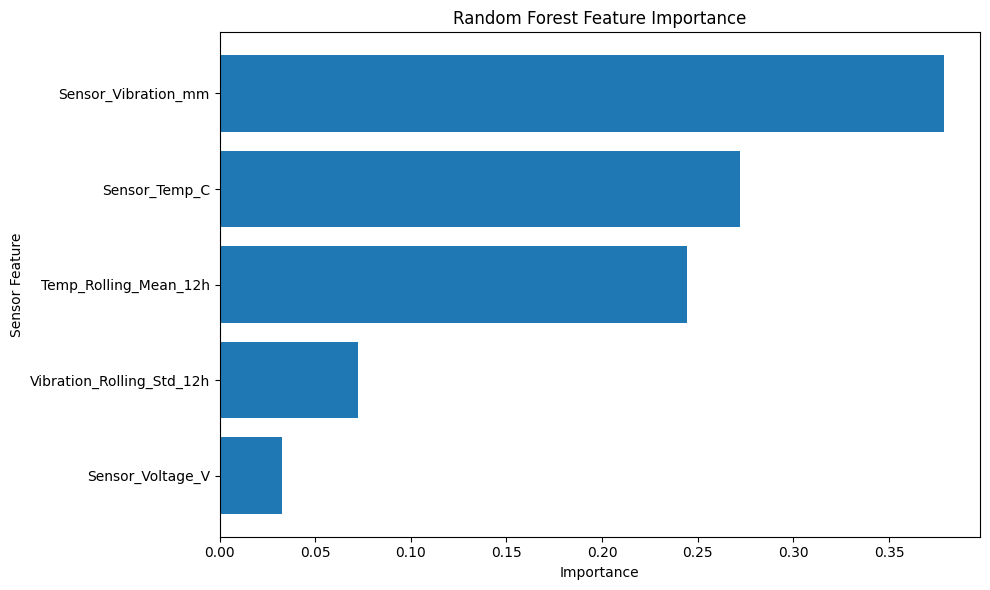

In [43]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Sensor Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [44]:
most_important_feature = feature_importance.iloc[0]

print("Most Important Feature")
print("----------------------")
print("Feature:", most_important_feature["Feature"])
print("Importance:", round(most_important_feature["Importance"], 4))

Most Important Feature
----------------------
Feature: Sensor_Vibration_mm
Importance: 0.3786


In [45]:
feature_importance_display = feature_importance.copy()

feature_importance_display["Importance (%)"] = (
    feature_importance_display["Importance"] * 100
).round(2)

print("Feature Importance Summary")
print("-------------------------")
print(
    feature_importance_display[
        ["Feature", "Importance (%)"]
    ].to_string(index=False)
)

Feature Importance Summary
-------------------------
                  Feature  Importance (%)
      Sensor_Vibration_mm           37.86
            Sensor_Temp_C           27.22
    Temp_Rolling_Mean_12h           24.42
Vibration_Rolling_Std_12h            7.23
         Sensor_Voltage_V            3.27


In [46]:
print("Business Recommendation")
print("-----------------------")

print(
    "The predictive maintenance model can be used to identify machines "
    "that may experience catastrophic failure within the next 24 hours. "
    "The system should prioritize machines flagged as high risk for "
    "inspection and preventive maintenance. Sensor features with higher "
    "feature importance should receive greater attention during monitoring. "
    "Using a lower prediction threshold increases the model's ability to "
    "detect potential failures, although it may also generate additional "
    "false alarms. Therefore, the threshold can be adjusted according to "
    "the organization's maintenance capacity and the cost of missed failures."
)

Business Recommendation
-----------------------
The predictive maintenance model can be used to identify machines that may experience catastrophic failure within the next 24 hours. The system should prioritize machines flagged as high risk for inspection and preventive maintenance. Sensor features with higher feature importance should receive greater attention during monitoring. Using a lower prediction threshold increases the model's ability to detect potential failures, although it may also generate additional false alarms. Therefore, the threshold can be adjusted according to the organization's maintenance capacity and the cost of missed failures.


In [47]:
print("PROJECT OVERHEAT - FINAL SUMMARY")
print("================================")

print(f"Dataset records used: {len(df)}")
print(f"Number of input features: {len(feature_columns)}")
print("Model: Random Forest Classifier")
print("Class balancing: Balanced class weights")
print("Data split: Chronological 80% training / 20% testing")
print(f"Decision threshold: {best_threshold:.2f}")
print(f"Test Accuracy: {threshold_accuracy:.4f}")
print(f"Test Precision: {threshold_precision:.4f}")
print(f"Test Recall: {threshold_recall:.4f}")
print(f"Test F1 Score: {threshold_f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nProject completed successfully!")

PROJECT OVERHEAT - FINAL SUMMARY
Dataset records used: 9965
Number of input features: 5
Model: Random Forest Classifier
Class balancing: Balanced class weights
Data split: Chronological 80% training / 20% testing
Decision threshold: 0.03
Test Accuracy: 0.9910
Test Precision: 0.1053
Test Recall: 0.6667
Test F1 Score: 0.1818
ROC-AUC: 0.9962

Project completed successfully!


In [48]:
print("FINAL DATASET CHECK")
print("===================")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["Failure_In_24_Hours"].value_counts())

FINAL DATASET CHECK
Dataset shape: (9965, 7)

Columns:
['Timestamp', 'Sensor_Temp_C', 'Sensor_Vibration_mm', 'Sensor_Voltage_V', 'Temp_Rolling_Mean_12h', 'Vibration_Rolling_Std_12h', 'Failure_In_24_Hours']

Missing values:
Timestamp                    0
Sensor_Temp_C                0
Sensor_Vibration_mm          0
Sensor_Voltage_V             0
Temp_Rolling_Mean_12h        0
Vibration_Rolling_Std_12h    0
Failure_In_24_Hours          0
dtype: int64

Target distribution:
Failure_In_24_Hours
0    9950
1      15
Name: count, dtype: int64


In [49]:
print("CHRONOLOGICAL SPLIT CHECK")
print("=========================")

print("Training start:", X_train.index.min())
print("Training end:", X_train.index.max())

print("Testing start:", X_test.index.min())
print("Testing end:", X_test.index.max())

print("\nNo random shuffling was used.")
print("Training data comes before testing data chronologically.")

CHRONOLOGICAL SPLIT CHECK
Training start: 0
Training end: 7971
Testing start: 7972
Testing end: 9964

No random shuffling was used.
Training data comes before testing data chronologically.


In [50]:
print("FINAL MODEL CONFIGURATION")
print("=========================")

print("Model: Random Forest Classifier")
print("Number of trees: 200")
print("Class weight: balanced")
print("Random state: 42")
print("Decision threshold:", round(best_threshold, 2))
print("Number of input features:", len(feature_columns))

print("\nFeatures used:")
for feature in feature_columns:
    print("-", feature)

FINAL MODEL CONFIGURATION
Model: Random Forest Classifier
Number of trees: 200
Class weight: balanced
Random state: 42
Decision threshold: 0.03
Number of input features: 5

Features used:
- Sensor_Temp_C
- Sensor_Vibration_mm
- Sensor_Voltage_V
- Temp_Rolling_Mean_12h
- Vibration_Rolling_Std_12h


In [51]:
print("=" * 55)
print("PROJECT OVERHEAT: PREDICTIVE MAINTENANCE AI")
print("=" * 55)

print("\nTIME-SERIES ENGINEERING")
print("✓ Timestamp parsed and chronologically sorted")
print("✓ 12-hour temperature rolling mean created")
print("✓ 12-hour vibration rolling standard deviation created")

print("\nTARGET ENGINEERING")
print("✓ Failure target shifted 24 hours into the future")
print("✓ Original failure column removed to prevent leakage")

print("\nMODEL")
print("✓ Chronological 80/20 train-test split")
print("✓ Random Forest with balanced class weights")
print("✓ Probability threshold optimized using validation data")

print("\nFINAL TEST RESULTS")
print(f"✓ Accuracy : {threshold_accuracy:.4f}")
print(f"✓ Precision: {threshold_precision:.4f}")
print(f"✓ Recall   : {threshold_recall:.4f}")
print(f"✓ F1 Score : {threshold_f1:.4f}")
print(f"✓ ROC-AUC  : {roc_auc:.4f}")

print("\nXAI")
print("✓ Feature importance calculated")
print("✓ Feature importance visualization created")

print("\nPROJECT STATUS: COMPLETED")

PROJECT OVERHEAT: PREDICTIVE MAINTENANCE AI

TIME-SERIES ENGINEERING
✓ Timestamp parsed and chronologically sorted
✓ 12-hour temperature rolling mean created
✓ 12-hour vibration rolling standard deviation created

TARGET ENGINEERING
✓ Failure target shifted 24 hours into the future
✓ Original failure column removed to prevent leakage

MODEL
✓ Chronological 80/20 train-test split
✓ Random Forest with balanced class weights
✓ Probability threshold optimized using validation data

FINAL TEST RESULTS
✓ Accuracy : 0.9910
✓ Precision: 0.1053
✓ Recall   : 0.6667
✓ F1 Score : 0.1818
✓ ROC-AUC  : 0.9962

XAI
✓ Feature importance calculated
✓ Feature importance visualization created

PROJECT STATUS: COMPLETED
